In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv("/content/Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.columns.to_list()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [6]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
df[df['Age'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [8]:
df[df["Age"].isna() & (df["Pclass"] == 3)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
29,30,0,3,"Todoroff, Mr. Lalio",male,NaN,0,0,349216,7.8958,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [10]:
x = df["Age"][(df["Pclass"] == 3) & (df['Sex'] == 'male')].mean()
y = df["Age"][(df["Pclass"] == 3) & (df['Sex'] == 'female')].mean()
print("Mean age of Male: " ,x)
print("Mean age of female: ",y)

Mean age of Male:  26.507588932806325
Mean age of female:  21.75


In [11]:
df.loc[(df["Age"].isna()) & (df["Pclass"] == 3) & (df["Sex"] == "male"), "Age"] = x # Fill missing Age values for males in 3rd class with x
df.loc[(df["Age"].isna()) & (df["Pclass"] == 3) & (df["Sex"] == "female"), "Age"] = y # Fill missing Age values for females in 3rd class with y
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,41
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
a = df["Age"][(df["Pclass"] == 1) & (df['Sex'] == 'male')].mean()
b = df["Age"][(df["Pclass"] == 1) & (df['Sex'] == 'female')].mean()
c = df["Age"][(df["Pclass"] == 2) & (df['Sex'] == 'male')].mean()
d = df["Age"][(df["Pclass"] == 2) & (df['Sex'] == 'female')].mean()
print(a , b , c , d  , sep= "\n")

41.28138613861386
34.61176470588235
30.74070707070707
28.722972972972972


In [13]:
df.loc[(df["Age"].isna()) & (df["Pclass"] == 1) & (df["Sex"] == "male"), "Age"] = a # Fill missing Age values for males in 1st class with a
df.loc[(df["Age"].isna()) & (df["Pclass"] == 1) & (df["Sex"] == "female"), "Age"] = b # Fill missing Age values for females in 1st class with b
df.loc[(df["Age"].isna()) & (df["Pclass"] == 2) & (df["Sex"] == "male"), "Age"] = c # Fill missing Age values for males in 2nd class with c
df.loc[(df["Age"].isna()) & (df["Pclass"] == 2) & (df["Sex"] == "female"), "Age"] = d # Fill missing Age values for females in 2nd class with d


In [14]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [15]:
df[df["Cabin"].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,26.507589,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.000000,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.000000,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.750000,1,2,W./C. 6607,23.4500,NaN,S


In [16]:
#Replace missing cabin values with 'HasNoCabin'
df["Cabin"] = df["Cabin"].fillna("HasNoCabin")
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [17]:
# Create a new column 'HasCabin': 1 if the passenger has a cabin, 0 if not
def HasCabin(cell):
    if cell == "HasNoCabin":
        return 0  # No cabin
    return 1      # Has a cabin

df["HasCabin"] = df["Cabin"].apply(HasCabin)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.2500,HasNoCabin,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.9250,HasNoCabin,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.0500,HasNoCabin,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.00,0,0,211536,13.0000,HasNoCabin,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.00,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.75,1,2,W./C. 6607,23.4500,HasNoCabin,S,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.00,0,0,111369,30.0000,C148,C,1


In [18]:
df[df["Embarked"].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,1
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,1


In [19]:
# Fill missing values in the 'Embarked' column with 'C' (Cherbourg)
df["Embarked"].fillna("C" , inplace= True)
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [20]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,HasCabin
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.318643,0.523008,0.381594,32.204208,0.228956
std,257.353842,0.486592,0.836071,13.281103,1.102743,0.806057,49.693429,0.420397
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,21.750000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,0.000000,3.000000,26.507589,0.000000,0.000000,14.454200,0.000000
75%,668.500000,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000,0.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [21]:
df[df["Age"]==df["Age"].max()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0,A23,S,1


In [22]:
df[df["Age"]==df["Age"].min()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,HasNoCabin,C,0


<Axes: title={'center': 'Age Distribution'}, xlabel='Age', ylabel='Count'>

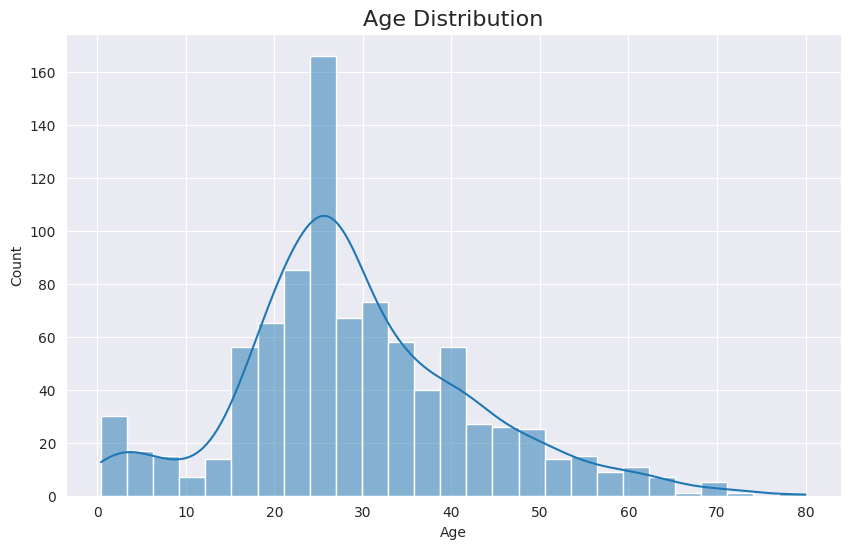

In [24]:
sns.set_style("darkgrid")
plt.figure(figsize=(10,6))
plt.title("Age Distribution",fontsize=16)
sns.histplot(df,x="Age",kde=True)

<Axes: title={'center': 'Age By Class'}, xlabel='Pclass', ylabel='Age'>

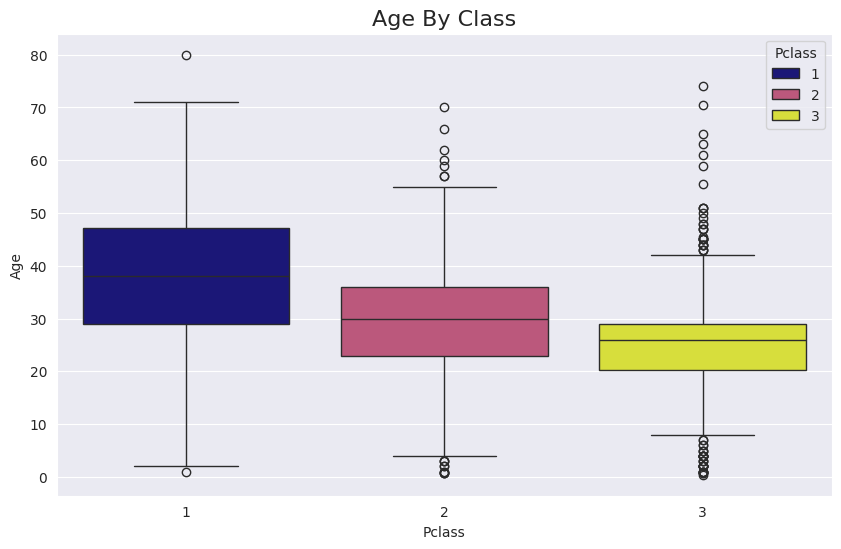

In [25]:
#Boxplot for Age vs. class
plt.figure(figsize=(10,6))
plt.title("Age By Class" , fontsize = 16)
sns.boxplot(x='Pclass', y='Age', data=df , hue= "Pclass" , palette= "plasma")

In [26]:
Q3 , Q1 = 36.000000 , 21.750000
IQR = Q3 - Q1
UB = Q3 + 1.5 * IQR
UB

57.375

In [27]:
outliers_Age = df[df["Age"] > UB]
outliers_Age

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,1
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,HasNoCabin,S,0
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C,1
94,95,0,3,"Coxon, Mr. Daniel",male,59.0,0,0,364500,7.2500,HasNoCabin,S,0
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C,1
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,HasNoCabin,Q,0
170,171,0,1,"Van der hoef, Mr. Wyckoff",male,61.0,0,0,111240,33.5000,B19,S,1
195,196,1,1,"Lurette, Miss. Elise",female,58.0,0,0,PC 17569,146.5208,B80,C,1
232,233,0,2,"Sjostedt, Mr. Ernst Adolf",male,59.0,0,0,237442,13.5000,HasNoCabin,S,0
252,253,0,1,"Stead, Mr. William Thomas",male,62.0,0,0,113514,26.5500,C87,S,1


# Age Outliers in Titanic Dataset¶
The oldest passengers are mostly in first class, but some are in second or third class without a cabin.



*   Most of them are males
*   Most of them did not survive (Survived = 0)


*   Most of them embarked from Southampton (Embarked = S)
*   Most of them have no siblings/spouses (SibSp = 0) and no parents/children (Parch = 0)


1.The youngest passenger (0.42 years) is naturally an infant but still represents an extreme value in the age distribution.

2.These values indicate that the dataset has a skewed distribution: most ages are between 20–40, with a few extreme values.

In [28]:
df[df["SibSp"] == df["SibSp"].max()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin
159,160,0,3,"Sage, Master. Thomas Henry",male,26.507589,8,2,CA. 2343,69.55,HasNoCabin,S,0
180,181,0,3,"Sage, Miss. Constance Gladys",female,21.750000,8,2,CA. 2343,69.55,HasNoCabin,S,0
201,202,0,3,"Sage, Mr. Frederick",male,26.507589,8,2,CA. 2343,69.55,HasNoCabin,S,0
324,325,0,3,"Sage, Mr. George John Jr",male,26.507589,8,2,CA. 2343,69.55,HasNoCabin,S,0
792,793,0,3,"Sage, Miss. Stella Anna",female,21.750000,8,2,CA. 2343,69.55,HasNoCabin,S,0
846,847,0,3,"Sage, Mr. Douglas Bullen",male,26.507589,8,2,CA. 2343,69.55,HasNoCabin,S,0
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,21.750000,8,2,CA. 2343,69.55,HasNoCabin,S,0


**Sage Family Summary**


*   Large 3rd class family group (Pclass = 3) traveling together.
*   All perished (Survived = 0).
*   All embarked from Southampton (S).
*   Mixed gender: mostly males, with females and children.
*  Large family onboard: SibSp = 8, Parch = 2.
*   No cabins
*   Ages range 21.75 - 26.51 yrs,mainly young adults and children.
*   Same ticket & fare for all,indicating a single booking










<Axes: title={'center': 'Fare Distribution'}, xlabel='Fare', ylabel='Count'>

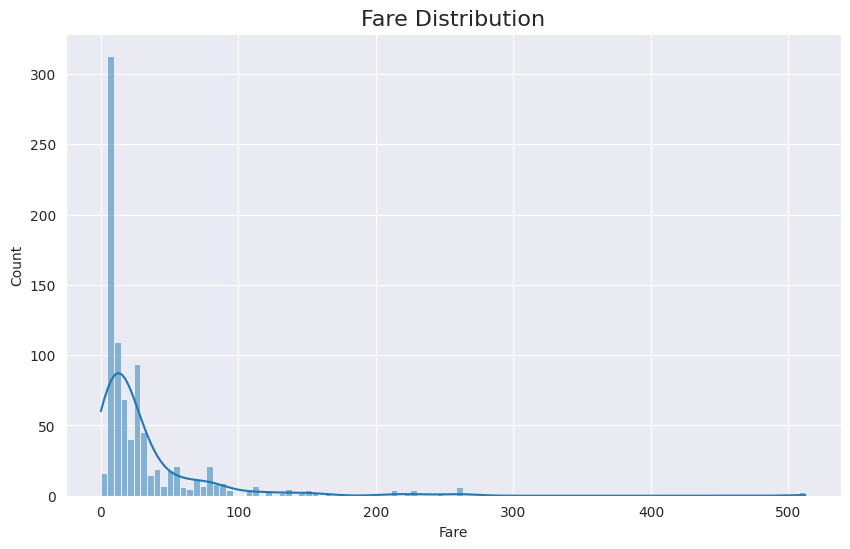

In [29]:
plt.figure(figsize=(10,6))
plt.title("Fare Distribution" , fontsize = 16)
sns.histplot(df , x="Fare" , kde=True)

In [31]:
import plotly.express as px
fig = px.box(df , x = "Sex" , y= "Fare" , color = "Sex" ,title="Fare Distribution by Sex", labels={"Sex": "Gender"})
fig.show()

In [32]:
df[df["Fare"] == df["Fare"].max()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,HasNoCabin,C,0
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,1
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,1


High fare, 1st class passengers traveling together had a high survival probability, even if not all had cabins

In [33]:
#Upper bound for fare
Q3 , Q1 = 31.000000 , 7.910400
IQR = Q3 - Q1
UB = Q3 + 1.5 * IQR
UB

65.6344

In [34]:
df[df["Fare"] > UB]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,1
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.000000,3,2,19950,263.0000,C23 C25 C27,S,1
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,34.611765,1,0,PC 17569,146.5208,B78,C,1
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.000000,1,0,PC 17604,82.1708,HasNoCabin,C,0
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.000000,1,0,PC 17572,76.7292,D33,C,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
846,847,0,3,"Sage, Mr. Douglas Bullen",male,26.507589,8,2,CA. 2343,69.5500,HasNoCabin,S,0
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,34.611765,1,0,17453,89.1042,C92,C,1
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.000000,1,1,36928,164.8667,HasNoCabin,S,0
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,21.750000,8,2,CA. 2343,69.5500,HasNoCabin,S,0


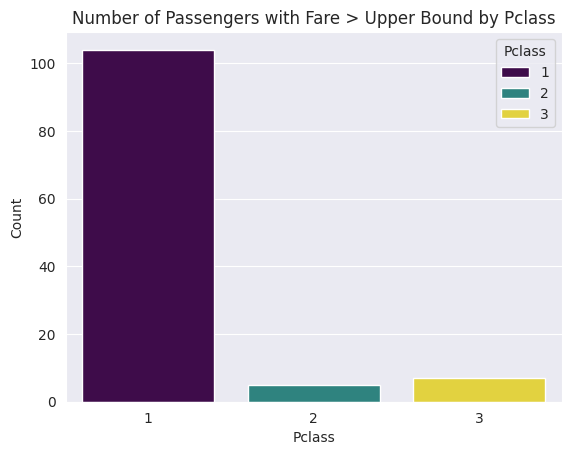

In [35]:
pclass_counts = df["Pclass"][df["Fare"] > UB].value_counts()
sns.barplot(x=pclass_counts.index, y=pclass_counts.values, palette="viridis" , hue= pclass_counts.index)
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.title("Number of Passengers with Fare > Upper Bound by Pclass")
plt.show()

**Highest Fares by Pclass**
1.Passengers who paid the highest fares mostly belong to 1st class (Pclass = 1).

2.This is expected, as 1st class tickets were the most expensive and luxurious.

3.Very few or no passengers from 2nd or 3rd class appear among the highest fares.

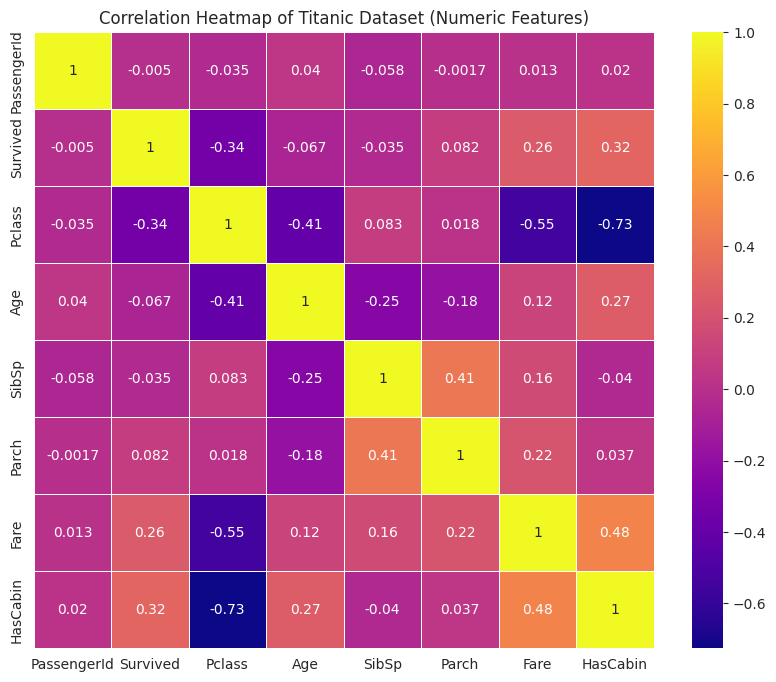

In [36]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap="plasma", linewidths=0.5)
plt.title("Correlation Heatmap of Titanic Dataset (Numeric Features)")
plt.show()

In [38]:
df.describe(include="O")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,891
unique,891,2,681,148,3
top,"Dooley, Mr. Patrick",male,347082,HasNoCabin,S
freq,1,577,7,687,644


In [39]:
pclass_pivot=df.pivot_table(index= "Pclass" , values= "Fare" , aggfunc= ["mean" , "sum"])
pclass_pivot

,mean,sum
,Fare,Fare
Pclass,,
1,84.154687,18177.4125
2,20.662183,3801.8417
3,13.675550,6714.6951


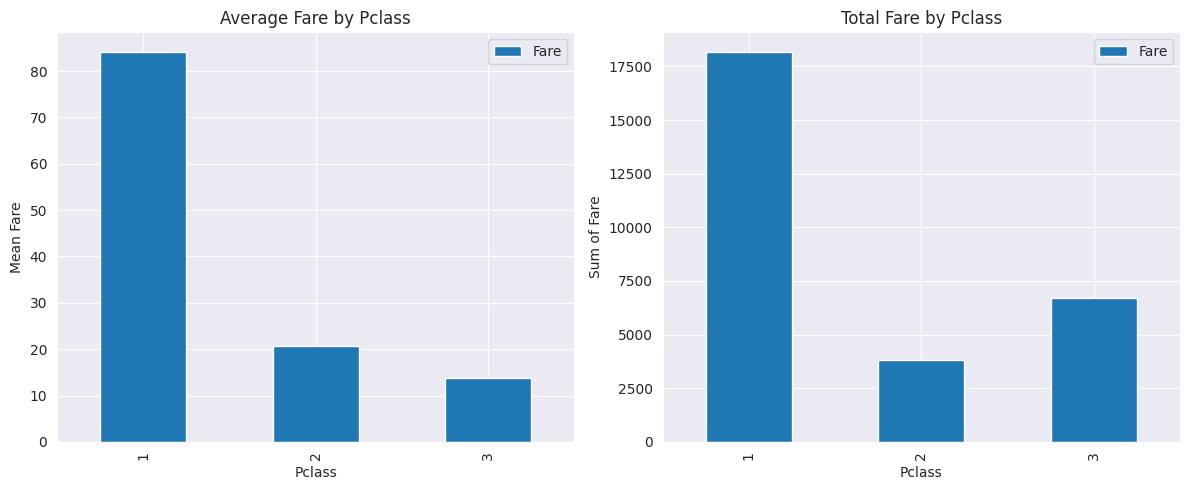

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pclass_pivot['mean'].plot(kind='bar', ax=axes[0], title='Average Fare by Pclass')
axes[0].set_ylabel('Mean Fare')
pclass_pivot['sum'].plot(kind='bar', ax=axes[1], title='Total Fare by Pclass')
axes[1].set_ylabel('Sum of Fare')
plt.tight_layout()
plt.show()

### Key Insights Fare Data
*   First Class passengers paid 4x more than Second Class (84.15 vs 20.66)
*  First Class paid 6x more than Third Class (84.15 vs 13.68)
*   Significant price gap between Second and Third Class (20.66 vs 13.68)
*   List item





In [41]:
embarked_pivot=df.pivot_table(index= "Embarked" , values= "Fare" , aggfunc= ["mean" , "sum"])
embarked_pivot

,mean,sum
,Fare,Fare
Embarked,,
C,60.189978,10232.2962
Q,13.276030,1022.2543
S,27.079812,17439.3988


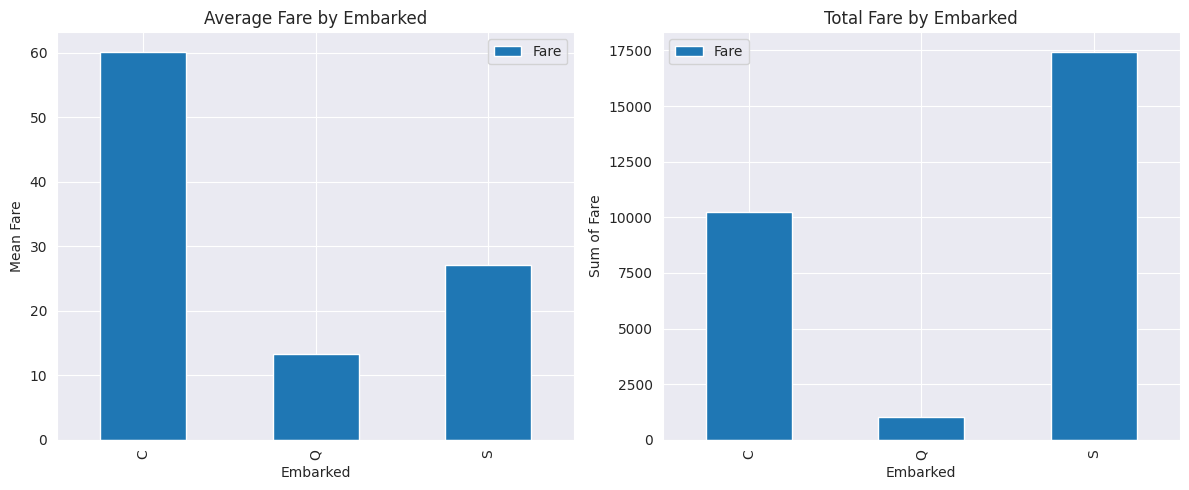

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
embarked_pivot['mean'].plot(kind='bar', ax=axes[0], title='Average Fare by Embarked')
axes[0].set_ylabel('Mean Fare')
embarked_pivot['sum'].plot(kind='bar', ax=axes[1], title='Total Fare by Embarked')
axes[1].set_ylabel('Sum of Fare')
plt.tight_layout()
plt.show()

**Embarkation Fare Data**
1.Cherbourg passengers paid 4.5x more than Queenstown passengers (60.19 vs 13.28).
2.Cherbourg passengers paid 2.2x more than Southampton passengers (60.19 vs 27.08).
3.Southampton passengers paid 2x more than Queenstown passengers (27.08 vs 13.28).

In [43]:
df["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [44]:
df["Embarked"].value_counts()

,count
Embarked,
S,644
C,170
Q,77


In [45]:
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


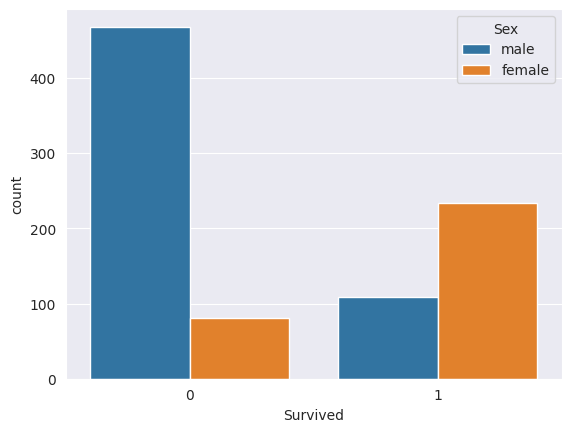

In [46]:
sns.countplot(data=df,x='Survived',hue='Sex')
plt.show()